This is an analysis of the *San Francisco Salaries* dataset acquired from the following link at [Kaggle](https://www.kaggle.com/datasets/kaggle/sf-salaries?resource=download).

The data is for San Francisco city employees from 2011-2014. This allows for a comparison in one broad category: how compensation is distributed and how it changed over the four-year period. This encompasses a variety of aspects.

Compensation distribution can refer to the whole government budget and within specific groups or positions. For example, looking at what portion of a position's compensation is overtime, and what portion of the whole budget goes towards IT Workers in general.

In [216]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt

In [217]:
con = sql.connect("Salaries.sqlite")
cur = con.cursor()

In [218]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
cur.execute(query)
tables = cur.fetchall()

In [219]:
columnDict = {}

for i,table in enumerate(tables):
    query = "SELECT * FROM %s;" % table
    cur.execute(query)
    cols = list(cur.description)
    valuelist = []
    for j, col in enumerate(cols):
        collist = list(col)
        valuelist.append(collist[0])
    columnDict[table] = valuelist

columnDict

{('Salaries',): ['Id',
  'EmployeeName',
  'JobTitle',
  'BasePay',
  'OvertimePay',
  'OtherPay',
  'Benefits',
  'TotalPay',
  'TotalPayBenefits',
  'Year',
  'Notes',
  'Agency',
  'Status']}

In [220]:
columnlabels = valuelist[3:9]
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where Year='""" + str(year) + """'"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,63595.956517,4531.065429,3617.081926,0.000000,71744.103871,71744.103871
2012,65436.406857,5023.417824,3653.437583,26439.966967,74113.262265,100553.229232
2013,68509.832156,5281.641980,3819.969007,23829.076572,77611.443142,101440.519714
2014,66557.437750,5401.426941,3505.053449,24787.000743,75463.918140,100250.918884
Whole Period,66053.729288,5065.923568,3648.669115,18924.232839,74768.321972,93692.554811


In [221]:
query = """ SELECT DISTINCT Notes from Salaries"""
cur.execute(query)
cur.fetchall()

[('',)]

In [222]:
query = """ SELECT DISTINCT Agency from Salaries"""
cur.execute(query)
cur.fetchall()

[('San Francisco',)]

In [223]:
query = """ SELECT DISTINCT Status from Salaries"""
cur.execute(query)
cur.fetchall()

[('',), ('PT',), ('FT',)]

In [224]:
query = """ SELECT Status, COUNT(Status) from Salaries GROUP By Status"""
cur.execute(query)
cur.fetchall()

[('', 110535), ('FT', 22334), ('PT', 15785)]

In [225]:
query = """SELECT COUNT(DISTINCT JobTitle) from Salaries"""
cur.execute(query)
cur.fetchmany(5)

[(2159,)]

In [226]:
query = """ SELECT DISTINCT Status from Salaries"""
cur.execute(query)
cur.fetchall()

[('',), ('PT',), ('FT',)]

Now I'll being look at the min, max, and average for each pay category, and investigating anything aberrant. 

In [227]:
query = """ SELECT MIN(BasePay), MAX(BasePay), AVG(BasePay) from Salaries where BasePay Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-166.01, 319275.01, 66325.44884048769)]

In [228]:
query = """ SELECT Year, MIN(BasePay), MAX(BasePay), AVG(BasePay) from Salaries where BasePay Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 294580.02, 63595.95651677314),
 (2012, -166.01, 302578, 65436.40685742262),
 (2013, 15.83, 319275.01, 69630.03021648063),
 (2014, 0, 318835.49, 66564.42192449959)]

In [229]:
query="Select JobTitle,BasePay from Salaries where BasePay < 0"
cur.execute(query)
cur.fetchall()

[('Junior Clerk', -166.01),
 ('Junior Clerk', -121.63),
 ('Junior Clerk', -109.22),
 ('Junior Clerk', -106.6),
 ('Junior Clerk', -101.88),
 ('Junior Clerk', -93.14),
 ('Junior Clerk', -87.38),
 ('Junior Clerk', -75.67),
 ('Junior Clerk', -59.59),
 ('Junior Clerk', -30.58),
 ('Clerk', -9.5)]

In [230]:
query="Select Count(JobTitle) from Salaries where JobTitle in ('Junior Clerk')"
cur.execute(query)
cur.fetchall()

[(596,)]

In [231]:
query="Select Count(JobTitle) from Salaries where JobTitle in ('Clerk')"
cur.execute(query)
cur.fetchall()

[(764,)]

For whatever reason, a small portion of the junior clerk and clerk base pay is negative.

In [232]:
query = """SELECT MIN(OvertimePay), MAX(OvertimePay), AVG(OvertimePay) from Salaries where OvertimePay Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-0.01, 245131.88, 5066.059886444668)]

In [233]:
query = """SELECT Year, MIN(OvertimePay), MAX(OvertimePay), AVG(OvertimePay) from Salaries where OvertimePay Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 245131.88, 4531.065428524019),
 (2012, 0, 220909.48, 5023.417824348583),
 (2013, -0.01, 196689.18, 5281.6419797372755),
 (2014, 0, 173547.73, 5401.993737243894)]

In [234]:
query="Select JobTitle,OvertimePay from Salaries where OvertimePay < 0"
cur.execute(query)
cur.fetchall()

[('Senior Eligibility Worker', -0.01)]

In [235]:
query = """ SELECT MIN(OtherPay), MAX(OtherPay), AVG(OtherPay) from Salaries where OtherPay Not in ('Not Provided')"""
cur.execute(query)
cur.fetchall()

[(-7058.59, 400184.25, 3648.767296804574)]

In [236]:
query = """SELECT Year, MIN(OtherPay), MAX(OtherPay), AVG(OtherPay) from Salaries where OtherPay Not in ('Not Provided') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 400184.25, 3617.0819259382174),
 (2012, 0, 245999.41, 3653.4375833650656),
 (2013, -7058.59, 202322.37, 3819.969006807424),
 (2014, -618.13, 342802.63, 3505.421250557465)]

In [237]:
query="Select JobTitle,OtherPay from Salaries where OtherPay < 0"
cur.execute(query)
cur.fetchall()

[('IS Business Analyst-Principal', -7058.59),
 ('Custodial Supervisor', -9.6),
 ('Gardener', -46.76),
 ('Special Nurse', -50.19),
 ('Counselor, Log Cabin Ranch', -618.13)]

In [238]:
query = """ SELECT MIN(Benefits), MAX(Benefits), AVG(Benefits) from Salaries where Benefits Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-33.89, 96570.66, 25007.89315082984)]

In [239]:
query = """ SELECT Year, MIN(Benefits), MAX(Benefits), AVG(Benefits) from Salaries where Benefits Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2012, 0, 84681.82, 26439.96696730675),
 (2013, -33.89, 86533.21, 23829.07657208956),
 (2014, -13.8, 96570.66, 24789.601756079646)]

In [240]:
query="Select JobTitle,Benefits from Salaries where Benefits < 0"
cur.execute(query)
cur.fetchall()

[('Police Officer 3', -2.73),
 ('Police Officer 3', -8.2),
 ('Police Officer 3', -33.89),
 ('Secretary 2', -13.8)]

In [241]:
query = """ SELECT MIN(TotalPay), MAX(TotalPay), AVG(TotalPay) from Salaries"""
cur.execute(query)
cur.fetchall()

[(-618.13, 567595.43, 74768.32197169265)]

In [242]:
query = """SELECT Year, MIN(TotalPay), MAX(TotalPay), AVG(TotalPay) from Salaries where TotalPay Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 567595.43, 71744.10387123538),
 (2012, 0, 362844.66, 74113.26226513626),
 (2013, 0, 347102.32, 77611.44314205181),
 (2014, -618.13, 471952.64, 75463.91814023031)]

In [243]:
query="Select JobTitle,TotalPay from Salaries where TotalPay < 0"
cur.execute(query)
cur.fetchall()

[('Counselor, Log Cabin Ranch', -618.13)]

In [244]:
query = """ SELECT MIN(TotalPayBenefits), MAX(TotalPayBenefits), AVG(TotalPayBenefits) from Salaries where TotalPayBenefits Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-618.13, 567595.43, 93692.55481056681)]

In [245]:
query = """ SELECT Year, MIN(TotalPayBenefits), MAX(TotalPayBenefits), AVG(TotalPayBenefits) from Salaries where TotalPayBenefits Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 567595.43, 71744.10387123538),
 (2012, 1.91, 407274.78, 100553.22923244302),
 (2013, -33.89, 425815.28, 101440.51971414135),
 (2014, -618.13, 510732.68, 100250.91888361356)]

In [246]:
query="Select JobTitle,TotalPayBenefits from Salaries where TotalPayBenefits < 0"
cur.execute(query)
cur.fetchall()

[('Police Officer 3', -2.73),
 ('Police Officer 3', -8.2),
 ('Police Officer 3', -33.89),
 ('Counselor, Log Cabin Ranch', -618.13)]

# Data Exploration

There are some strange outliers such as jobs with negative base pay that will likely pop up as the exploration and analysis continues. Based on the dataframe, the averages are fairly consistent, except for the glaring 0 benefit average in 2011. In general, 2011 is below average for the different pay categories and by a decent margine (63000 vs 66000 for average base pay). This may be due to budget cuts in 2011 and 2012 as per a [San Francisco Gate Article](https://www.sfgate.com/bayarea/article/Police-staffing-expected-to-shrink-2459144.php#ixzz1Gb2OcXrN), or some other reason.

With the broad strokes established, mainly what possible values there are for each category, the focus can be shifted towards comparing and contrasting different groups of employees. Most of these are curiosities outside of a handful.

The benefits will be looked at over time, as well as the distribution of job titles and if they change in name. Some positions may be renamed and won't be picked up by the **LIKE** command parameters set up. 

I'll be looking at the following:

* **Law Enforcement**: by looking at the strings *Police* and *Sheriff* I can see the Law Enforcement wages paid by the city.
* **Fire Department**: By taking a look at the string *Fire* I can see how much is spent on the Fire Department in terms of wages.
* **Mayor**: by querying 'Mayor' to take a look at the mayor and their staff.
* **Healthcare**: This one is a variety of strings that are cut off to bring in the largest variety of job titles. The list is *nurs* (gets nurse and nursery), *medical*, *health*, *dent*, *pharma* (pharmacy and pharmacist), *Physician*, and *Social Work*. This should get most healthcare workers though with so many strings it will probably get a few incorrect ones which is why I will also try to avoid the strings *resources* and *examiner*. 
* **Information Science**: All of the IT/IS positions start with 'IS' so looking for that with a space afterwards should get all of those positions without having to filter too many other job titles.
* **Justice**: *Defender* should pick up Public Defenders and *court* should pick up most who work at the court. Judge did not seem to get many results which is strange, and even looking for it directly did not give any results aside from a secretary.
* **Engineers and Scientists**: Looking at the strings *bio*, *chem*, *research* and *engineer* should get all the relevant job titles. This is to see how much money is spent on research, development, and engineers in general.
* **Planning**: Looking at the string *plann* should get all job titles related to urban planning.
* **Technicians and Mechanics**: *automotive*, *Electr*, *mech*, *plumb* should get all handymen, mechanics, and technicians. This is to see how much is spent on maintenance work and similar tasks.
* **Clerks**: *clerk* and *secretar* should bring up all clerks, secretaries and other clerical staff to see how much is spent on office staff.

In [247]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries WHERE JobTitle LIKE '%Judge%'"""
cur.execute(query)
cur.fetchall()

[('SECRETARY TO THE PRESIDING JUDGE', 2904666.62, 2011)]

## Law Enforcement Jobs

In [323]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,98670.938358,8873.547690,10583.457149,0.000000,118127.943197,118127.943197
2012,91507.501294,12292.643799,7542.632845,31017.148832,111342.777938,142359.926770
2013,96100.881809,13353.038508,8722.163789,31413.608814,118176.084106,149589.692920
2014,91428.937813,14200.600170,8503.300340,32588.774938,114132.838323,146721.613261
Whole Period,94649.070771,11998.871340,8929.840666,22470.903528,115577.782778,138048.686306


In [248]:
query = """SELECT COUNT(DISTINCT(JobTitle)) from Salaries 
WHERE JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%'"""
cur.execute(query)
cur.fetchall()

[(63,)]

In [249]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle), Year from Salaries 
WHERE JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%' 
Group by JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('AIRPORT POLICE SERVICES AIDE', 11244297.15, 60129.93128342246, 187, 2011),
 ('ASSISTANT INSPECTOR (POLICE DEPARTMENT)', 188999.2, 188999.2, 1, 2011),
 ('ASSISTANT INSPECTOR II (POLICE DEPARTMENT)',
  1508888.61,
  150888.861,
  10,
  2011),
 ('ASSISTANT INSPECTOR III (POLICE DEPARTMENT)',
  1374040.94,
  152671.21555555554,
  9,
  2011),
 ('ASSISTANT SHERIFF', 189675.09, 94837.545, 2, 2011),
 ('Assistant Sheriff', 767179.29, 191794.8225, 4, 2012),
 ('CAPTAIN III (POLICE DEPARTMENT)', 7836004.05, 211783.89324324325, 37, 2011),
 ('CHIEF DEPUTY SHERIFF', 503875.24, 167958.41333333333, 3, 2011),
 ('CHIEF OF POLICE', 267992.59, 267992.59, 1, 2011),
 ('COMMANDER III, (POLICE DEPARTMENT)',
  1435955.55,
  205136.50714285715,
  7,
  2011),
 ('Chief Deputy Sheriff', 2181134.48, 218113.448, 10, 2012),
 ('Chief of Police', 1235196.8, 411732.26666666666, 3, 2012),
 ('Community Police Services Aide', 51794326.06, 92655.32389982112, 559, 2012),
 ('DEPUTY CHIEF III (POLICE DEPARTMENT)',
  1250132.

In [250]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2011' AND (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('AIRPORT POLICE SERVICES AIDE', 11244297.15, 60129.93128342246, 187),
 ('ASSISTANT INSPECTOR (POLICE DEPARTMENT)', 188999.2, 188999.2, 1),
 ('ASSISTANT INSPECTOR II (POLICE DEPARTMENT)', 1508888.61, 150888.861, 10),
 ('ASSISTANT INSPECTOR III (POLICE DEPARTMENT)',
  1374040.94,
  152671.21555555554,
  9),
 ('ASSISTANT SHERIFF', 189675.09, 94837.545, 2),
 ('CAPTAIN III (POLICE DEPARTMENT)', 7836004.05, 211783.89324324325, 37),
 ('CHIEF DEPUTY SHERIFF', 503875.24, 167958.41333333333, 3),
 ('CHIEF OF POLICE', 267992.59, 267992.59, 1),
 ('COMMANDER III, (POLICE DEPARTMENT)', 1435955.55, 205136.50714285715, 7),
 ('DEPUTY CHIEF III (POLICE DEPARTMENT)', 1250132.44, 250026.48799999998, 5),
 ('DEPUTY SHERIFF', 64951787.99, 94820.12845255475, 685),
 ('INSPECTOR II, (POLICE DEPARTMENT)',
  432848.20999999996,
  144282.73666666666,
  3),
 ('INSPECTOR III, (POLICE DEPARTMENT)', 24968457.92, 154126.28345679014, 162),
 ('INSPECTOR, (POLICE DEPARTMENT)', 318997.97, 159498.985, 2),
 ('INSTITUTIONAL 

In [251]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2012' AND (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Assistant Sheriff', 261249.93, 130624.965, 2),
 ('Chief Deputy Sheriff', 772327.6, 193081.9, 4),
 ('Chief of Police', 391362.3, 391362.3, 1),
 ('Community Police Services Aide', 17022524.97, 95097.90486033518, 179),
 ('Deputy Sheriff', 90260344.97, 136139.2835143288, 663),
 ('Deputy Sheriff 1', 291234.74, 32359.415555555555, 9),
 ('Inspector, (Police Department)', 389651.99, 194825.995, 2),
 ('Institutional Police Officer', 1284354.38, 107029.53166666666, 12),
 ('Institutional Police Sergeant', 349038.82999999996, 174519.41499999998, 2),
 ('Police Officer', 51445336.71, 122781.23319809069, 419),
 ('Police Officer 2', 68668793.7, 162337.57375886524, 423),
 ('Police Officer 3', 138076018.47, 159810.2065625, 864),
 ('Police Services Aide', 60968.55, 60968.55, 1),
 ('Senior Deputy Sheriff', 13674136.34, 155387.91295454546, 88),
 ('Sergeant, (Police Department)', 2842573.24, 177660.8275, 16),
 ('Sheriff', 19891.46, 19891.46, 1),
 ('Sheriff (SFERS)', 256636.3, 256636.3, 1),
 ("Sheriff's C

In [252]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2013' AND (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Assistant Sheriff', 246135.72, 246135.72, 1),
 ('Chief Deputy Sheriff', 702560.07, 234186.68999999997, 3),
 ('Chief of Police', 425815.28, 425815.28, 1),
 ('Community Police Services Aide', 16505787.14, 93253.03468926554, 177),
 ('Deputy Sheriff', 93750724.8, 143569.25696784072, 653),
 ('Deputy Sheriff 1', 2388737.16, 54289.48090909091, 44),
 ('Inspector, (Police Department)', 428154.08999999997, 142718.03, 3),
 ('Institutional Police Officer', 1324675.09, 101898.08384615385, 13),
 ('Institutional Police Sergeant', 320286.06000000006, 160143.03000000003, 2),
 ('Police Officer', 64347754.07, 127927.94049701789, 503),
 ('Police Officer 2', 68171160.25, 177992.5855091384, 383),
 ('Police Officer 3', 134598825.71, 173900.2916149871, 774),
 ('Senior Deputy Sheriff', 13398366.82, 161426.10626506025, 83),
 ('Sergeant, (Police Department)', 2605813.9, 200447.22307692308, 13),
 ('Sheriff (SFERS)', 298551.11, 298551.11, 1),
 ("Sheriff's Cadet", 2725059.54, 56772.07375, 48),
 ("Sheriff's Capta

In [253]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2014' AND (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Assistant Sheriff', 259793.64, 259793.64, 1),
 ('Chief Deputy Sheriff', 706246.81, 235415.60333333336, 3),
 ('Chief of Police', 418019.22, 418019.22, 1),
 ('Community Police Services Aide', 18266013.95, 89980.36428571428, 203),
 ('Deputy Sheriff', 92239944.64, 149497.4791572123, 617),
 ('Deputy Sheriff (SFERS)', 1981418.08, 123838.63, 16),
 ('Deputy Sheriff 1', 2335930.6, 93437.224, 25),
 ('Inspector, (Police Department)', 220410.34, 220410.34, 1),
 ('Institutional Police Officer', 1263729.57, 105310.7975, 12),
 ('Institutional Police Sergeant', 361014.1, 180507.05, 2),
 ('Lieutenant (Police Department)', 186913.98, 186913.98, 1),
 ('Police Officer', 67365805.01, 121598.92601083033, 554),
 ('Police Officer 2', 58739406.98, 175341.5133731343, 335),
 ('Police Officer 3', 133415475.56, 170390.1348148148, 783),
 ('Senior Deputy Sheriff', 13298249.2, 168332.26835443036, 79),
 ('Sergeant, (Police Department)', 1774740.37, 197193.37444444446, 9),
 ('Sheriff (SFERS)', 300529.16, 300529.16, 

In [254]:
query = """SELECT SUM(TotalPayBenefits), AVG(TotalPayBenefits), Count(Year), Year from Salaries 
WHERE JobTitle LIKE '%Police%' OR  JobTitle LIKE '%Sheriff%' 
Group by Year Order by Year"""
cur.execute(query)
cur.fetchall()

[(410140218.78, 118127.9431970046, 3472, 2011),
 (405868151.22, 142359.92676955456, 2851, 2012),
 (420047857.72, 149589.69292022794, 2808, 2013),
 (413901671.01, 146721.61326125488, 2821, 2014)]

### First Discussion

Interestingly, 2011 seems to be anomalous compared to the other three years. 2012-2014 all have and average pay and benefits between 140 and 150 thousand, with a total staff of around 2800, and a total budget for staff of 400-420 million. 2011 has a similar budget with 600 more staff and an average salary with benefits of a bit below 120000. Quickly looking over the job titles for each year reveals that 2011 uniquely has *AIRPORT POLICE SERVICES AIDE*, *'POLICE COMMUNICATIONS SHIFT SUPERVISOR*, and *SENIOR POLICE COMMUNICATIONS DISPATCHER* which account for around 200 employees and around 15 million in pay and benefits. An additional 45 million in pay and benefits can be found with the Sergeant III position found in the 2011 data set across 300 employees. The first set of positions have a lower average pay and benefits than 140,000. 

This is corroborated by the table set up at the beginning comparing the average of each pay type in each year and overall. Benefits were 0 in 2011, as expected though just comparing total pay makes it seem a lot more even, with the loss in overtime pay being equal to the gain in other pay. Effectively, the whole difference between 2011 and the rest are the benefits, though there are some inconsisitencies with positions that should be looked at.

It's highly likely that the positions were renamed so trying to match **Police** and **Sheriff** won't pick it up, though the Sergeant III position was probably just absorbed under another job title. This means it would be good to rerun the previous SQL query removing the aforementioned positions to see how the numbers compare.

In [257]:
query = """SELECT  SUM(TotalPayBenefits), AVG(TotalPayBenefits), Count(Year), Year from Salaries 
WHERE (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
AND (JobTitle NOT LIKE '%communications%' AND Jobtitle NOT LIKE '%airport%') 
GROUP By Year Order by Year"""
cur.execute(query)
cur.fetchall()

[(395799064.1, 121672.01478635106, 3253, 2011),
 (405868151.22, 142359.92676955456, 2851, 2012),
 (420047857.72, 149589.69292022794, 2808, 2013),
 (413901671.01, 146721.61326125488, 2821, 2014)]

In [258]:
query = """SELECT JobTitle, COUNT(JobTitle) from Salaries 
WHERE Jobtitle LIKE '%Captain%' OR Jobtitle LIKE '%Lieutenant%' OR Jobtitle LIKE '%cadet%' 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('CAPTAIN III (POLICE DEPARTMENT)', 37),
 ('CAPTAIN, BUREAU OF FIRE PREVENTION AND PUBLIC SAFE', 1),
 ('CAPTAIN, EMERGENCYCY MEDICAL SERVICES', 24),
 ('CAPTAIN, FIRE SUPPRESSION', 71),
 ('Captain 3', 101),
 ('Captain, (Fire Department)', 1),
 ('Captain, Emergency Med Svcs', 75),
 ('Captain, Fire Suppression', 211),
 ('INSTITUTIONAL POLICE LIEUTENANT', 1),
 ('LIEUTENANT I, (POLICE DEPARTMENT)', 1),
 ('LIEUTENANT II (POLICE DEPARTMENT)', 1),
 ('LIEUTENANT III (POLICE DEPARTMENT)', 98),
 ('LIEUTENANT, BUREAU OF FIRE PREVENTION AND PUBLIC S', 8),
 ('LIEUTENANT, FIRE DEPARTMENT', 170),
 ('Lieutenant (Police Department)', 1),
 ('Lieutenant 2', 7),
 ('Lieutenant 3', 303),
 ('Lieutenant, Fire Suppression', 572),
 ("SHERIFF'S CADET", 64),
 ("SHERIFF'S CAPTAIN", 8),
 ("SHERIFF'S LIEUTENANT", 37),
 ("Sheriff's Cadet", 186),
 ("Sheriff's Captain", 23),
 ("Sheriff's Lieutenant", 103)]

In [259]:
query = """SELECT JobTitle, COUNT(JobTitle) from Salaries 
WHERE Jobtitle LIKE '%Captain%' OR Jobtitle LIKE '%CPT%' OR Jobtitle LIKE '%cadet%' 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('CAPTAIN III (POLICE DEPARTMENT)', 37),
 ('CAPTAIN, BUREAU OF FIRE PREVENTION AND PUBLIC SAFE', 1),
 ('CAPTAIN, EMERGENCYCY MEDICAL SERVICES', 24),
 ('CAPTAIN, FIRE SUPPRESSION', 71),
 ('Captain 3', 101),
 ('Captain, (Fire Department)', 1),
 ('Captain, Emergency Med Svcs', 75),
 ('Captain, Fire Suppression', 211),
 ("SHERIFF'S CADET", 64),
 ("SHERIFF'S CAPTAIN", 8),
 ("Sheriff's Cadet", 186),
 ("Sheriff's Captain", 23)]

In [260]:
query = """SELECT JobTitle, COUNT(JobTitle) from Salaries 
WHERE Jobtitle LIKE '%Sergeant%' 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('INSTITUTIONAL POLICE SERGEANT', 2),
 ('Institutional Police Sergeant', 6),
 ('SERGEANT I (POLICE DEPARTMENT)', 17),
 ('SERGEANT II (POLICE DEPARTMENT)', 19),
 ('SERGEANT III (POLICE DEPARTMENT)', 295),
 ("SHERIFF'S SERGEANT", 55),
 ('Sergeant 2', 131),
 ('Sergeant 3', 1047),
 ('Sergeant, (Police Department)', 38),
 ("Sheriff's Sergeant", 153)]

In [261]:
query = """SELECT JobTitle, COUNT(JobTitle) from Salaries 
WHERE Year='2012' AND (Jobtitle LIKE '%Sergeant%' OR Jobtitle LIKE '%SGT%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Institutional Police Sergeant', 2),
 ('Sergeant 2', 22),
 ('Sergeant 3', 317),
 ('Sergeant, (Police Department)', 16),
 ("Sheriff's Sergeant", 50)]

In [262]:
query = """SELECT JobTitle, COUNT(JobTitle) from Salaries 
WHERE Year='2013' AND (Jobtitle LIKE '%Sergeant%' OR Jobtitle LIKE '%SGT%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Capt,Fire Prev or Fire Invsgtn', 7),
 ('Institutional Police Sergeant', 2),
 ('Sergeant 2', 55),
 ('Sergeant 3', 361),
 ('Sergeant, (Police Department)', 13),
 ("Sheriff's Sergeant", 53)]

In [263]:
query = """SELECT JobTitle, COUNT(JobTitle) from Salaries 
WHERE Year='2014' AND (Jobtitle LIKE '%Sergeant%' OR Jobtitle LIKE '%SGT%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Capt,Fire Prev or Fire Invsgtn', 7),
 ('Institutional Police Sergeant', 2),
 ('Sergeant 2', 54),
 ('Sergeant 3', 369),
 ('Sergeant, (Police Department)', 9),
 ("Sheriff's Sergeant", 50)]

In [264]:
query = """SELECT Year, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Jobtitle LIKE '%Sergeant%' OR Jobtitle LIKE '&SGT%' 
GROUP By Year Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[(2011, 56731648.09, 146215.58786082474, 388),
 (2012, 76630901.02, 188282.31208845208, 407),
 (2013, 98967307.4, 204477.9078512397, 484),
 (2014, 97891786.55, 202255.75733471074, 484)]

In [265]:
query = """SELECT Year, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Jobtitle LIKE '%lieutenant%' 
GROUP By Year Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[(2011, 51151974.97, 161873.33851265823, 316),
 (2012, 70384376.46, 213285.98927272725, 330),
 (2013, 74491359.92, 226417.5073556231, 329),
 (2014, 71893239.42, 219857.00128440367, 327)]

In [266]:
query = """SELECT Year, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Jobtitle LIKE '%captain%' 
GROUP By Year Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[(2011, 26186044.27, 185716.6260283688, 141),
 (2012, 33575285.82, 243299.17260869566, 138),
 (2014, 34926113.26, 247702.9309219858, 141),
 (2013, 33892915.55, 256764.51174242422, 132)]

### Second Discussion

The difference in employment from year to year becomes less significant when taking a title like *sergeant* or *captain* makes the difference smaller. There is a somewhat constant amount of captains, lieutenants, and sergeants over time though the benefits are much worse in 2011. This may be due to the aforementioned budget cuts, or that there is any aspect that I am missing for this. I figure budget cuts are more likely since the average pay benefits are much lower even for effectively the same position (within sergeants or captains for example).

Aside from the quirks of 2011, the distribution and compensation of positions is basically consistent. There are differences, of course, like the fact that 2014 had an uptick in the number of Community Police Services Aides, and Sheriff's Cadets (each increased by about 30) as well as a loss of around 50 Police Officer II's without that being fully reflected in other roles such as Police Officer III's (which did have a bit of an uptick), or Police Sergeants. The changes between 2012 and 2013 are fairly minimal, with a decently significant decrease of Sheriff's Cadets (from 60 down to 48), albeit with a parallel increase of Deputy Sheriff 1's from 9 to 44.

Basically, the number of personnel is basically constant, which can be seen from the previous look into captains, sergeants, and lieutenants, and from ignoring the positions such as *AIRPORT POLICE SERVICES AIDE* in 2011 which were likely absorbed into other positions either in or out of the police department.

#### Next Steps
What's left is taking a look at Status (Number of full time versus part time employees), portion of overtime pay, benefits pay, and base pay. It is important to note that most jobs are not actually labeled as full or part time so that will be a minimally important aspect of the comparison.

I will be looking at the ratio of each of these payments since that will make it easier to compare from job grouping to job grouping. Additionally, I will be looking at positions as a whole rather than each individual job because it helps understand the general trend for jobs. Outliers should get smoothed out by doing this and it will help see which positions typically have large amounts of benefits or overtime which can help determine which positions are understaffed or are being pushed by offering generous benefits.

In [267]:
query = """SELECT AVG(TotalPayBenefits), Status, COUNT(Status) from Salaries 
WHERE (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By Status Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[(135369.2068470047, '', 9131),
 (163835.18180519482, 'FT', 2310),
 (69358.90614481409, 'PT', 511)]

In [268]:
query = """SELECT Year, JobTitle, AVG(BasePay)/AVG(TotalPayBenefits) as 'Base Pay Ratio', AVG(OvertimePay)/AVG(TotalPayBenefits) as 'Overtime Ratio', AVG(OtherPay) / AVG(TotalPayBenefits) as 'Other Pay Ratio', AVG(Benefits)/AVG(TotalPayBenefits) as 'Benefits Ratio' from Salaries 
WHERE (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By JobTitle, Year Order by JobTitle"""
df = pd.read_sql_query(query, con)
df.head()

,Year,JobTitle,Base Pay Ratio,Overtime Ratio,Other Pay Ratio,Benefits Ratio
0,2011,AIRPORT POLICE SERVICES AIDE,0.851136,0.091118,0.057746,0.0
1,2011,ASSISTANT INSPECTOR (POLICE DEPARTMENT),0.651696,0.241693,0.106611,0.0
2,2011,ASSISTANT INSPECTOR II (POLICE DEPARTMENT),0.847419,0.089785,0.062795,0.0
3,2011,ASSISTANT INSPECTOR III (POLICE DEPARTMENT),0.854647,0.087599,0.057754,0.0
4,2011,ASSISTANT SHERIFF,0.995391,0.000000,0.004609,0.0


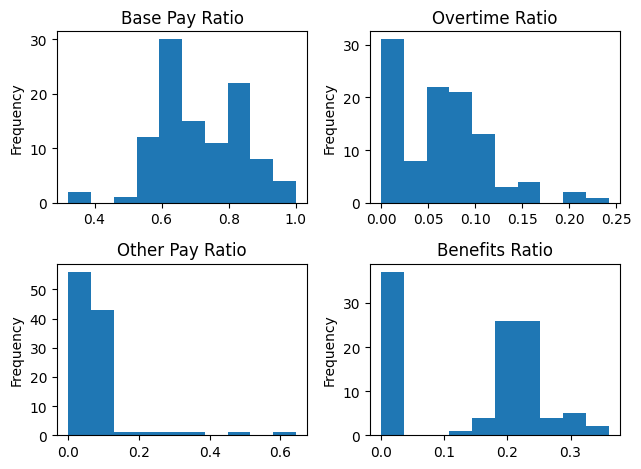

In [269]:
fig, axes = plt.subplots(nrows=2, ncols=2)
df['Base Pay Ratio'].plot(kind='hist',ax=axes[0,0], title='Base Pay Ratio')
df['Overtime Ratio'].plot(kind='hist',ax=axes[0,1], title='Overtime Ratio')
df['Other Pay Ratio'].plot(kind='hist',ax=axes[1,0], title='Other Pay Ratio')
df['Benefits Ratio'].plot(kind='hist',ax=axes[1,1], title='Benefits Ratio')
fig.tight_layout()

I'll be using the median to divide the histogram into two halves.

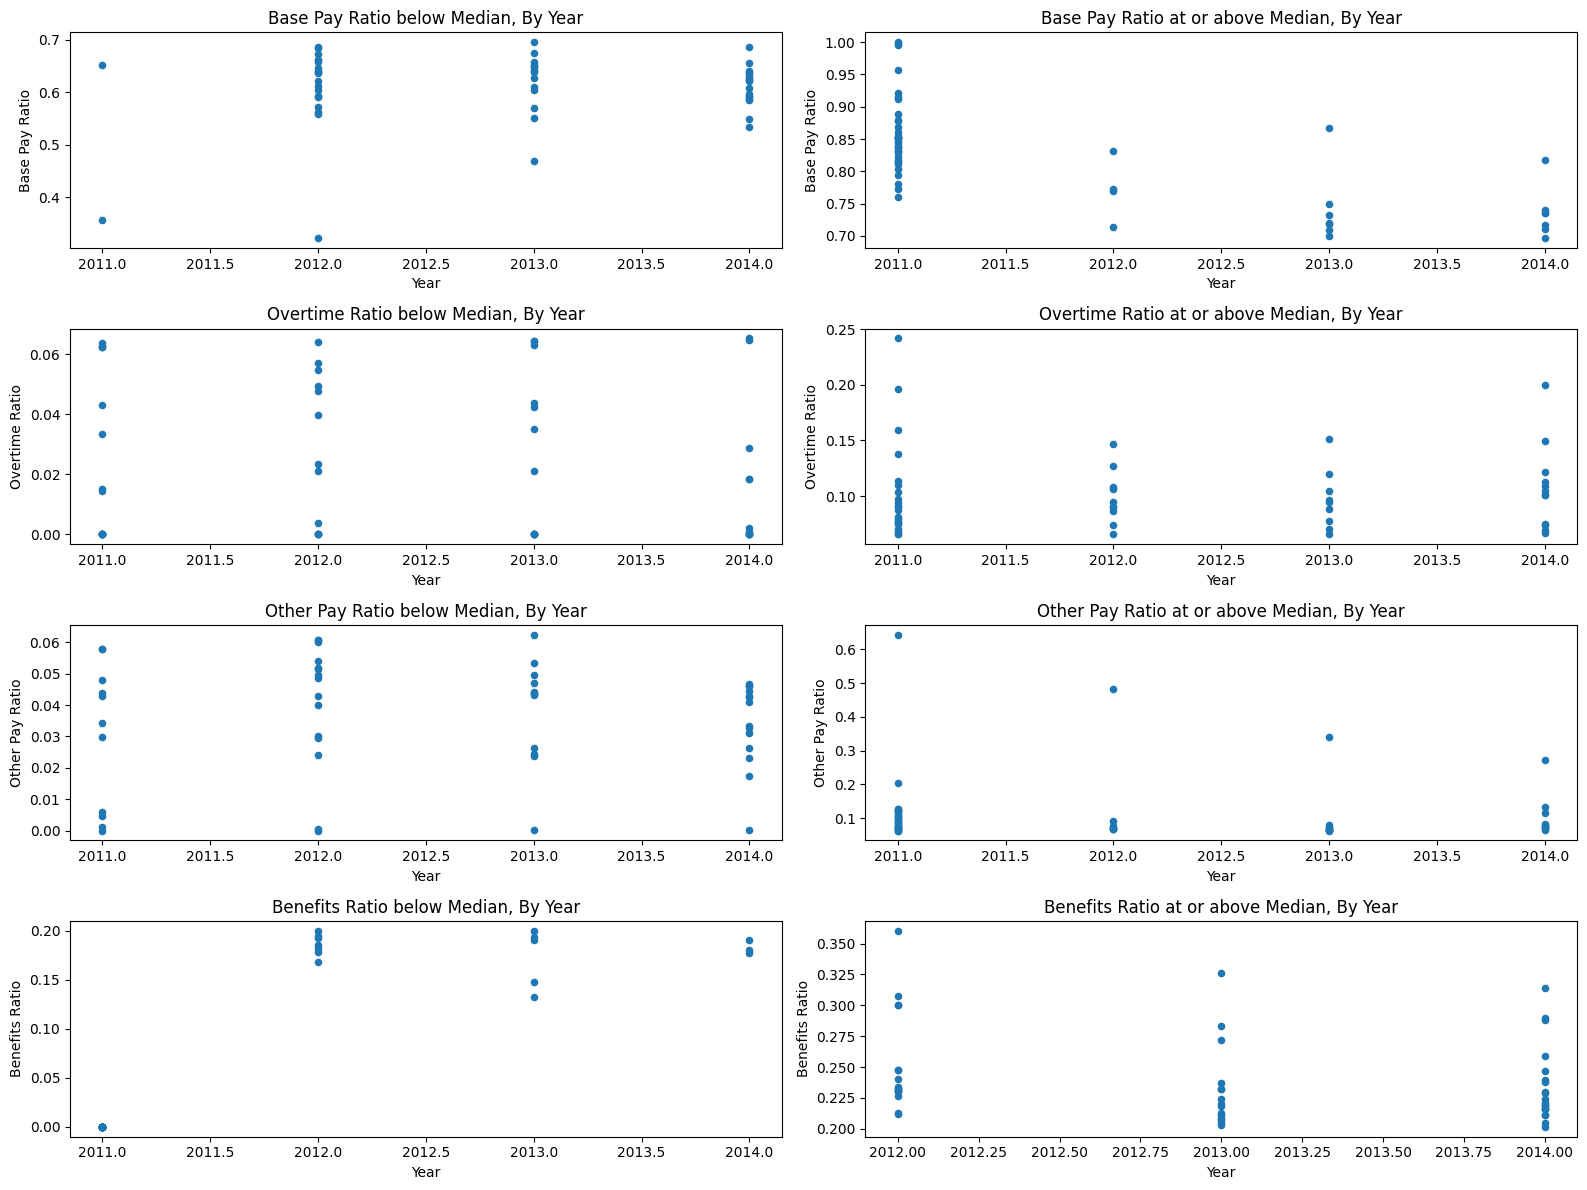

In [270]:
medians = list(df.median(numeric_only=True))

fig, axes = plt.subplots(nrows=4, ncols=2)
df[df['Base Pay Ratio'] < medians[1]].plot(kind='scatter',ax=axes[0,0], x='Year', y='Base Pay Ratio', title='Base Pay Ratio below Median, By Year')
df[df['Base Pay Ratio'] >= medians[1]].plot(kind='scatter',ax=axes[0,1], x='Year', y='Base Pay Ratio', title='Base Pay Ratio at or above Median, By Year')
df[df['Overtime Ratio'] < medians[2]].plot(kind='scatter',ax=axes[1,0], x='Year', y='Overtime Ratio',title='Overtime Ratio below Median, By Year')
df[df['Overtime Ratio'] >= medians[2]].plot(kind='scatter',ax=axes[1,1], x='Year', y='Overtime Ratio',title='Overtime Ratio at or above Median, By Year')
df[df['Other Pay Ratio'] < medians[3]].plot(kind='scatter',ax=axes[2,0], x='Year', y='Other Pay Ratio',title='Other Pay Ratio below Median, By Year')
df[df['Other Pay Ratio'] >= medians[3]].plot(kind='scatter',ax=axes[2,1], x='Year', y='Other Pay Ratio',title='Other Pay Ratio at or above Median, By Year')
df[df['Benefits Ratio'] < medians[4]].plot(kind='scatter',ax=axes[3,0], x='Year', y='Benefits Ratio',title='Benefits Ratio below Median, By Year')
df[df['Benefits Ratio'] >= medians[4]].plot(kind='scatter',ax=axes[3,1], x='Year', y='Benefits Ratio',title='Benefits Ratio at or above Median, By Year')
fig.set_size_inches(16,12)
fig.tight_layout()

In [271]:
df[(df['Benefits Ratio'] < 0.201482) & (df['Year'] == 2011)]

,Year,JobTitle,Base Pay Ratio,Overtime Ratio,Other Pay Ratio,Benefits Ratio
0,2011,AIRPORT POLICE SERVICES AIDE,0.851136,0.091118,0.057746,0.0
1,2011,ASSISTANT INSPECTOR (POLICE DEPARTMENT),0.651696,0.241693,0.106611,0.0
2,2011,ASSISTANT INSPECTOR II (POLICE DEPARTMENT),0.847419,0.089785,0.062795,0.0
3,2011,ASSISTANT INSPECTOR III (POLICE DEPARTMENT),0.854647,0.087599,0.057754,0.0
4,2011,ASSISTANT SHERIFF,0.995391,0.000000,0.004609,0.0
8,2011,CAPTAIN III (POLICE DEPARTMENT),0.803571,0.074956,0.121473,0.0
9,2011,CHIEF DEPUTY SHERIFF,0.911967,0.014514,0.073519,0.0
10,2011,CHIEF OF POLICE,0.957006,0.000000,0.042994,0.0
11,2011,"COMMANDER III, (POLICE DEPARTMENT)",0.814300,0.077007,0.108692,0.0
21,2011,DEPUTY CHIEF III (POLICE DEPARTMENT),0.878942,0.000000,0.121058,0.0


<Axes: xlabel='Year', ylabel='AVG(OvertimePay)'>

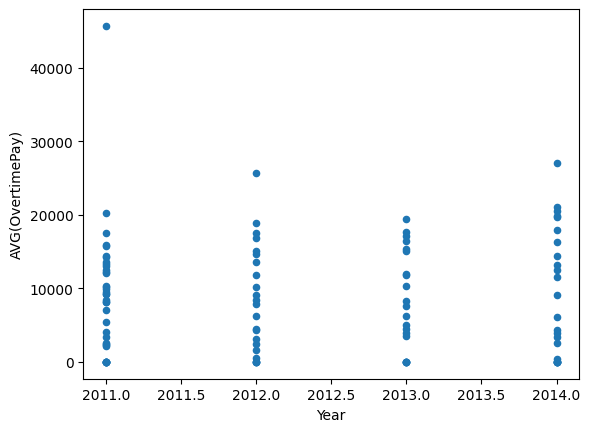

In [272]:
query = """SELECT JobTitle, Year, AVG(OvertimePay), SUM(OvertimePay) from Salaries 
WHERE (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%') 
GROUP By JobTitle,Year Order by JobTitle"""
df = pd.read_sql_query(query, con)
df.plot.scatter(x='Year', y='AVG(OvertimePay)')

Going back to the previously mentioned San Francisco Gate article, it seems like 2011 was hit by budget cuts that reduced the benefits but not the Other Pay and overtime compensation for the police department. No positions had any benefits as part of their pay, and the overtime pay clustered around 7.5 to 11% of total comepnsation which is close to the amount of the others. However, Base Pay compensation makes up 80% or more of total compensation which is much more than other years, which gives insight into how little supplementary compensation like overtime and benefits made up of total compensation in 2011.

Other than that the values seem mostly consistent. Other Pay Rations took a bit of a hit in 2014 but nothing else is obvious.

## Fire Department Jobs

In [273]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%Fire%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%Fire%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,106549.269212,21863.252762,16593.143509,0.000000,145005.665483,145005.665483
2012,109222.646825,27949.994562,15312.756073,36479.662036,152485.397460,188965.059496
2013,114488.499062,30122.528760,15948.846651,38781.470384,160559.874473,199341.344856
2014,108179.287505,25562.627240,15052.835347,40177.332819,148794.750093,188972.082912
Whole Period,109598.760177,26365.376705,15721.675498,28948.448195,151685.812380,180634.260575


In [274]:
query = """SELECT SUM(TotalPayBenefits), AVG(TotalPayBenefits), Count(JobTitle) from Salaries 
WHERE JobTitle LIKE '%Fire%' 
Group by Year Order by Year"""
cur.execute(query)
cur.fetchall()

[(211563265.94, 145005.66548320767, 1459),
 (273810371.21, 188965.05949620425, 1449),
 (291038363.49, 199341.3448561644, 1460),
 (285536817.28, 188972.0829119788, 1511)]

In [275]:
query = """SELECT COUNT(DISTINCT(JobTitle)) from Salaries 
WHERE JobTitle LIKE '%Fire%'"""
cur.execute(query)
cur.fetchall()

[(40,)]

### First Discussion

Similar to the law enforcement section, 2011 is the only one that seems obviously different from the other years. 2011 has a significantly lower average and total compensation, though with roughly the same number of positions. There are no benefits, and that basically accounts for the difference in total compensation, though it is larger than just the benefits gap. There is the downtick in base pay, as well as over time that is partially compensated rfor by the uptick in other pay, though not fully.

Speaking on that, 2014 does have a notable increase in the number of positions found so that is something to look at.

Comparing again to the law enforcement analysis, there are far fewer distinct positions (63 for law enforcement and 40 for the fire department) in this set than that one.

In [276]:
query = """SELECT Year, JobTitle, AVG(BasePay)/AVG(TotalPayBenefits) as 'Base Pay Ratio', AVG(OvertimePay)/AVG(TotalPayBenefits) as 'Overtime Ratio', AVG(OtherPay) / AVG(TotalPayBenefits) as 'Other Pay Ratio', AVG(Benefits)/AVG(TotalPayBenefits) as 'Benefits Ratio' from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By JobTitle, Year Order by JobTitle"""
df = pd.read_sql_query(query, con)
df.head()

,Year,JobTitle,Base Pay Ratio,Overtime Ratio,Other Pay Ratio,Benefits Ratio
0,2011,"ASSISTANT CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)",0.647016,0.199997,0.152987,0.000000
1,2012,Asst Chf of Dept (Fire Dept),0.626040,0.124796,0.077761,0.171402
2,2013,Asst Chf of Dept (Fire Dept),0.600716,0.149488,0.077032,0.172764
3,2014,Asst Chf of Dept (Fire Dept),0.598003,0.127719,0.085903,0.188376
4,2011,"BATTALION CHIEF, (FIRE DEPARTMENT)",0.668689,0.162079,0.169233,0.000000


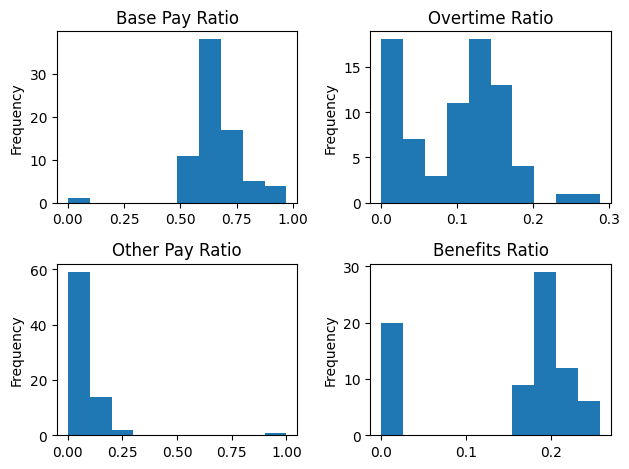

In [277]:
fig, axes = plt.subplots(nrows=2, ncols=2)
df['Base Pay Ratio'].plot(kind='hist',ax=axes[0,0], title='Base Pay Ratio')
df['Overtime Ratio'].plot(kind='hist',ax=axes[0,1], title='Overtime Ratio')
df['Other Pay Ratio'].plot(kind='hist',ax=axes[1,0], title='Other Pay Ratio')
df['Benefits Ratio'].plot(kind='hist',ax=axes[1,1], title='Benefits Ratio')
fig.tight_layout()

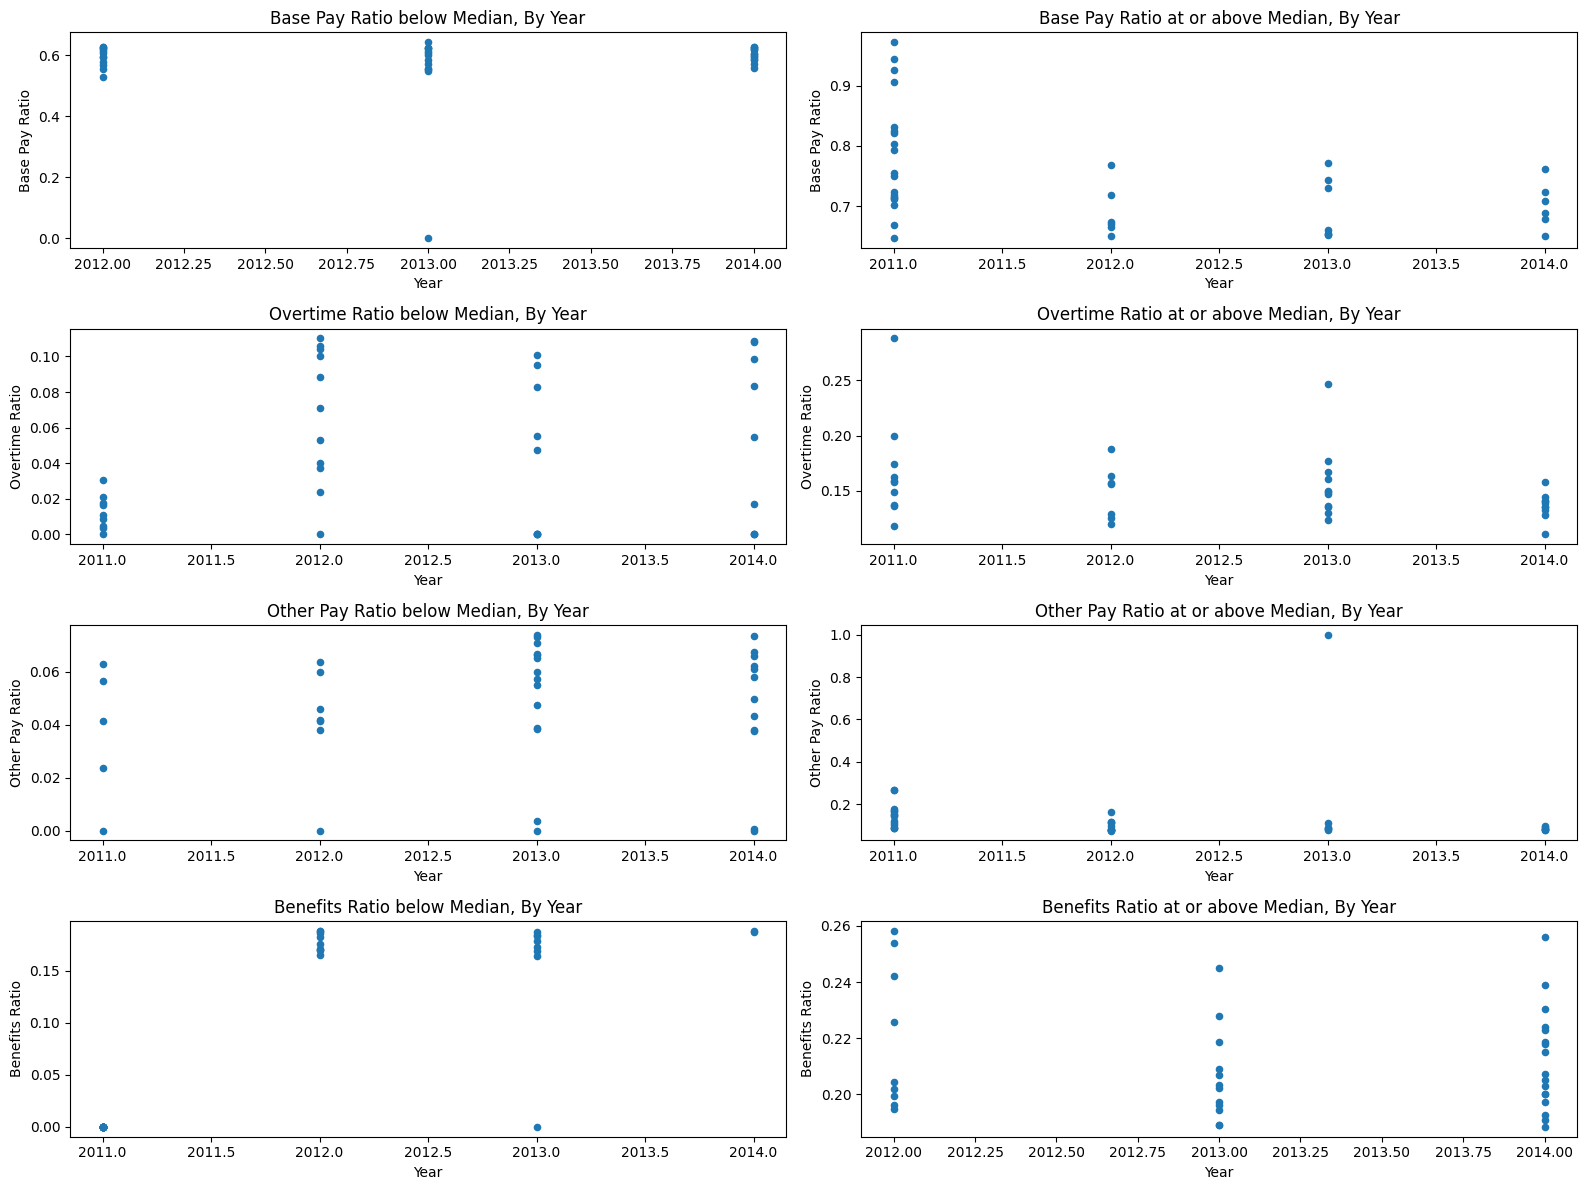

In [278]:
medians = list(df.median(numeric_only=True))

fig, axes = plt.subplots(nrows=4, ncols=2)
df[df['Base Pay Ratio'] < medians[1]].plot(kind='scatter',ax=axes[0,0], x='Year', y='Base Pay Ratio', title='Base Pay Ratio below Median, By Year')
df[df['Base Pay Ratio'] >= medians[1]].plot(kind='scatter',ax=axes[0,1], x='Year', y='Base Pay Ratio', title='Base Pay Ratio at or above Median, By Year')
df[df['Overtime Ratio'] < medians[2]].plot(kind='scatter',ax=axes[1,0], x='Year', y='Overtime Ratio',title='Overtime Ratio below Median, By Year')
df[df['Overtime Ratio'] >= medians[2]].plot(kind='scatter',ax=axes[1,1], x='Year', y='Overtime Ratio',title='Overtime Ratio at or above Median, By Year')
df[df['Other Pay Ratio'] < medians[3]].plot(kind='scatter',ax=axes[2,0], x='Year', y='Other Pay Ratio',title='Other Pay Ratio below Median, By Year')
df[df['Other Pay Ratio'] >= medians[3]].plot(kind='scatter',ax=axes[2,1], x='Year', y='Other Pay Ratio',title='Other Pay Ratio at or above Median, By Year')
df[df['Benefits Ratio'] < medians[4]].plot(kind='scatter',ax=axes[3,0], x='Year', y='Benefits Ratio',title='Benefits Ratio below Median, By Year')
df[df['Benefits Ratio'] >= medians[4]].plot(kind='scatter',ax=axes[3,1], x='Year', y='Benefits Ratio',title='Benefits Ratio at or above Median, By Year')
fig.set_size_inches(16,12)
fig.tight_layout()

<Axes: xlabel='Year', ylabel='AVG(OvertimePay)'>

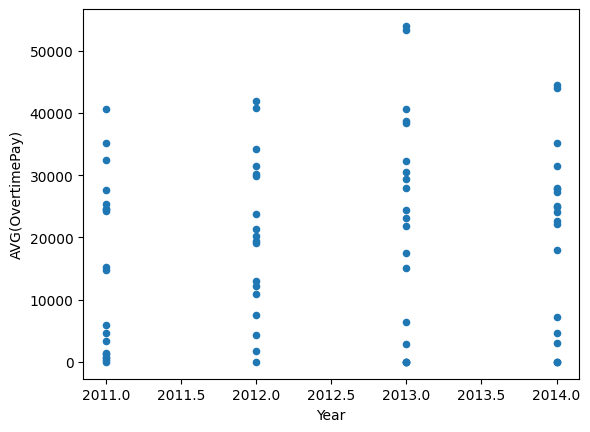

In [279]:
query = """SELECT JobTitle, Year, AVG(OvertimePay), SUM(OvertimePay) from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By JobTitle,Year Order by JobTitle"""
df = pd.read_sql_query(query, con)
df.plot.scatter(x='Year', y='AVG(OvertimePay)')

### Second Discussion

There are similarities between the law enforcement and fire department analyses. For example, the Base Pay Ratios are clustered from around 0.70 to 1.00 while the other years are generally below 0.8 with many positions clustered around 0.60.

Benefits are 0% of compensation in 2011, just like law enforcement in 2011, and overtime is a higher percentage of compensation for this year, in comparison to the others. This makes sense since benefits were eliminated for that year. Overtime compensation is mostly unaffected just like for law enforcement.

So it seems like the budget cuts also affected the fire department.

As a side note, the fire department has quite a bit of overtime pay.

Now it's time to poke around 2011 to see if the change in pay is solely due to the reduction of benefits or not.

<Axes: xlabel='Year', ylabel='AVG(TotalPay)'>

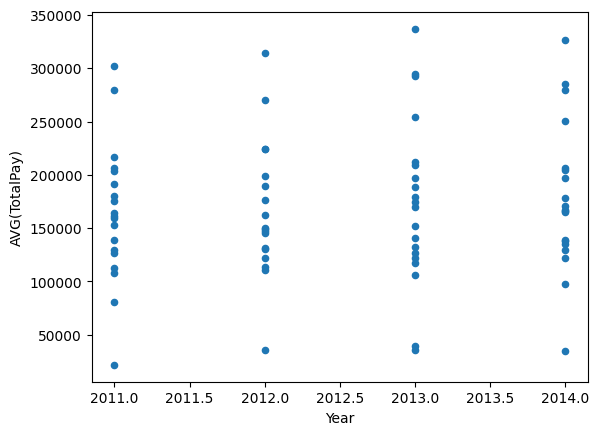

In [280]:
query = """SELECT JobTitle, Year, AVG(TotalPay) from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By JobTitle,Year Order by JobTitle"""
df = pd.read_sql_query(query, con)
df.plot.scatter(x='Year', y='AVG(TotalPay)')

In [281]:
query = """SELECT Year, AVG(TotalPay) from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 145005.66548320767),
 (2012, 152485.39746031744),
 (2013, 160559.87447260274),
 (2014, 148794.75009265385)]

In [282]:
query = """SELECT Year, AVG(TotalPayBenefits) from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 145005.66548320767),
 (2012, 188965.05949620425),
 (2013, 199341.3448561644),
 (2014, 188972.0829119788)]

In [283]:
query = """SELECT Year, AVG(OtherPay) from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 16593.143509252914),
 (2012, 15312.7560731539),
 (2013, 15948.84665068493),
 (2014, 15052.835347452019)]

In [284]:
query = """SELECT Year, AVG(OvertimePay) from Salaries 
WHERE JobTitle LIKE '%Fire%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 21863.252762165866),
 (2012, 27949.994561766733),
 (2013, 30122.528760273974),
 (2014, 25562.627240238253)]

In [285]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2011' AND (JobTitle LIKE '%Fire%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('ASSISTANT CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)', 610283.55, 203427.85, 3),
 ('BATTALION CHIEF, (FIRE DEPARTMENT)', 9749499.16, 216655.5368888889, 45),
 ('CAPTAIN, BUREAU OF FIRE PREVENTION AND PUBLIC SAFE',
  206704.63,
  206704.63,
  1),
 ('CAPTAIN, FIRE SUPPRESSION', 12762877.81, 179758.8423943662, 71),
 ('CHIEF FIRE ALARM DISPATCHER', 112798.37, 112798.37, 1),
 ('CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)', 302377.73, 302377.73, 1),
 ('DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)', 838078.68, 279359.56, 3),
 ('FIRE ALARM DISPATCHER', 130371.56999999999, 21728.594999999998, 6),
 ('FIRE FIGHTER PARAMEDIC', 38957981.84, 129428.51109634552, 301),
 ('FIRE PROTECTION ENGINEER', 507207.46, 126801.865, 4),
 ('FIRE RESCUE PARAMEDIC', 566616.29, 80945.18428571429, 7),
 ('FIRE SAFETY INSPECTOR II', 1678561.17, 152596.47, 11),
 ('FIREFIGHTER', 110597884.48, 139292.0459445844, 794),
 ('INSPECTOR, BUREAU OF FIRE PREVENTION AND PUBLIC SA',
  3220814.25,
  161040.7125,
  20),
 ('INVESTIGATOR, BURE

In [286]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2012' AND (JobTitle LIKE '%Fire%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Asst Chf of Dept (Fire Dept)', 1959996.8, 326666.13333333336, 6),
 ('Battlion Chief, Fire Suppressi', 9671884.74, 268663.465, 36),
 ('Captain, Fire Suppression', 17748108.07, 243124.7680821918, 73),
 ('Chief Fire Alarm Dispatcher', 161410.9, 161410.9, 1),
 ('Chief, Fire Department', 386807.48, 386807.48, 1),
 ('Dep Chf of Dept (Fire Dept)', 810440.36, 270146.7866666667, 3),
 ('EMT/Paramedic/Firefighter', 50556803.75, 163086.46370967742, 310),
 ('Fire Alarm Dispatcher', 241197.11000000002, 48239.422000000006, 5),
 ('Fire Protection Engineer', 710514.37, 177628.5925, 4),
 ('Fire Rescue Paramedic', 571991.72, 142997.93, 4),
 ('Fire Safety Inspector 2', 2126886.42, 193353.3109090909, 11),
 ('Firefighter', 138455936.8, 182418.88906455864, 759),
 ('Insp, Fire Dept', 4613609.25, 200591.70652173914, 23),
 ('Invstgtor,Fire Dept', 723928.35, 180982.0875, 4),
 ('Lieut,Fire Prev', 2052441.3, 228049.03333333333, 9),
 ('Lieutenant, Fire Suppression', 41597840.29, 217789.73973821988, 191),
 ('Mari

In [287]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2013' AND (JobTitle LIKE '%Fire%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Asst Chf of Dept (Fire Dept)', 2138544.03, 356424.00499999995, 6),
 ('Battalion Chief, Fire Suppress', 10365573.45, 304869.80735294113, 34),
 ('Capt,Fire Prev or Fire Invsgtn', 1800056.8599999999, 257150.97999999998, 7),
 ('Captain, (Fire Department)', 35332.78, 35332.78, 1),
 ('Captain, Fire Suppression', 17428750.25, 260130.60074626867, 67),
 ('Chief Fire Alarm Dispatcher', 164262.95, 164262.95, 1),
 ('Chief, Fire Department', 422353.4, 422353.4, 1),
 ('Dep Chf of Dept (Fire Dept)', 740812.6399999999, 370406.31999999995, 2),
 ('EMT/Paramedic/Firefighter', 52354156.97, 176276.62279461278, 297),
 ('Fire Alarm Dispatcher', 364062.76, 52008.96571428572, 7),
 ('Fire Protection Engineer', 630137.12, 157534.28, 4),
 ('Fire Rescue Paramedic', 671191.92, 134238.38400000002, 5),
 ('Fire Safety Inspector 2', 2154822.9, 215482.28999999998, 10),
 ('Firefighter', 148689770.25, 189413.72006369426, 785),
 ('Insp, Fire Dept', 4647323.1, 211241.95909090908, 22),
 ('Invstgtor,Fire Dept', 450483.09, 

In [288]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), AVG(TotalPayBenefits), COUNT(JobTitle) from Salaries 
WHERE Year = '2014' AND (JobTitle LIKE '%Fire%') 
GROUP By JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('Asst Chf of Dept (Fire Dept)', 2068215.08, 344702.51333333337, 6),
 ('Battalion Chief, Fire Suppress', 9586472.48, 309241.0477419355, 31),
 ('Capt,Fire Prev or Fire Invsgtn', 1779590.68, 254227.24, 7),
 ('Captain, Fire Suppression', 17581855.38, 247631.76591549296, 71),
 ('Chief Fire Alarm Dispatcher', 131663.78, 131663.78, 1),
 ('Chief, Fire Department', 417435.1, 417435.1, 1),
 ('Dep Chf of Dept (Fire Dept)', 736012.7, 368006.35, 2),
 ('EMT/Paramedic/Firefighter', 51220488.92, 164696.10585209003, 311),
 ('Fire Alarm Dispatcher', 343830.01, 42978.75125, 8),
 ('Fire Protection Engineer', 725546.0900000001, 181386.52250000002, 4),
 ('Fire Rescue Paramedic', 527038.8, 175679.6, 3),
 ('Fire Safety Inspector 2', 2077225.28, 207722.528, 10),
 ('Firefighter', 144827011.84, 177701.85501840492, 815),
 ('Insp, Fire Dept', 6052270.04, 208698.96689655172, 29),
 ('Invstgtor,Fire Dept', 430812.91000000003, 215406.45500000002, 2),
 ('Lieut,Fire Prev', 2285242.31, 253915.81222222222, 9),
 ('Lieute

The drop in pay is due to a drop in benefits and pay in general, but there are also a handful of interesting things to note between 2011 and th rest of the years. For whatever reason, 2011 had only 3 Assitant Chiefs of the Department, while the other years had 6. Additionally, there are a handful of positions that had a smaller number of positions in 2011, though they are not as significant as law enforcement. For example, 2011 had 170 Lieutenants, and future years would have around 190 Lieutenants. Interestingly, they changed the name of the positions from *'LIEUTENANT, FIRE DEPARTMENT'* to *'Lieutenant, Fire Suppression'*.

## Mayoral Jobs

In [289]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%Mayor%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%Mayor%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,72703.560000,0.000000,2678.606000,0.000000,75382.166000,75382.166000
2012,87973.065652,0.000000,304.622609,39674.454130,88277.688261,127952.142391
2013,87297.189286,10.761250,639.234286,35254.440714,87947.184821,123201.625536
2014,87137.065246,0.000000,669.208525,36485.656066,87806.273770,124291.929836
Whole Period,83971.561502,2.829249,1054.280657,28285.908873,85028.671408,113314.580282


In [290]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%mayor%' 
Group by JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[('MAYOR', 268411.42, 2011),
 ("MAYOR'S PROGRAM MANAGER", 89197.2, 2011),
 ('MAYORAL STAFF II', 35398.8, 2011),
 ('MAYORAL STAFF IV', 89052.9, 2011),
 ('MAYORAL STAFF IX', 144636.75, 2011),
 ('MAYORAL STAFF V', 13223.8, 2011),
 ('MAYORAL STAFF VII', 161275.47, 2011),
 ('MAYORAL STAFF X', 154911.46, 2011),
 ('MAYORAL STAFF XI', 12196.8, 2011),
 ('MAYORAL STAFF XII', 136054.6, 2011),
 ('MAYORAL STAFF XIII', 422973.49, 2011),
 ('MAYORAL STAFF XIV', 169859.66999999998, 2011),
 ('MAYORAL STAFF XV', 854504.16, 2011),
 ('MAYORAL STAFF XVI', 566859.42, 2011),
 ('MAYORAL STAFF XVII', 650552.36, 2011),
 ('Mayor', 1062638.72, 2012),
 ('Mayoral Staff II', 485938.29, 2012),
 ('Mayoral Staff IV', 706283.63, 2012),
 ('Mayoral Staff IX', 1486400.98, 2012),
 ('Mayoral Staff V', 398491.84, 2012),
 ('Mayoral Staff VII', 403431.15, 2012),
 ('Mayoral Staff X', 324566.97000000003, 2012),
 ('Mayoral Staff XI', 1686057.91, 2012),
 ('Mayoral Staff XII', 253881.1, 2012),
 ('Mayoral Staff XIII', 1860455.39000000

In [291]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%Staff III' 
Group by JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[]

In [292]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE 'Mayoral Staff III' 
Group by JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[]

In [293]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE 'Mayoral Staff VI' 
Group by JobTitle Order by JobTitle"""
cur.execute(query)
cur.fetchall()

[]

In [294]:
query = """SELECT SUM(TotalPayBenefits), AVG(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%mayor%' 
Group by Year Order by Year"""
cur.execute(query)
cur.fetchall()

[(3769108.3, 75382.166, 2011),
 (5885798.55, 127952.14239130434, 2012),
 (6899291.03, 123201.6255357143, 2013),
 (7581807.72, 124291.92983606557, 2014)]

In [295]:
query = """SELECT COUNT(DISTINCT(JobTitle)) from Salaries 
WHERE JobTitle LIKE '%mayor%'"""
cur.execute(query)
cur.fetchall()

[(29,)]

### First Discussion

This looks like the most signficant change from 2011 to the other years, plus it seems to be missing several positions for whatever reason. For example, *Mayoral Staff III* seems to not exist, among other tiers of persumably pay.

Additionally the change in total and average pay between 2011 and onwards is also the greatest, so far. The change in average pay between 2011 and 2012 is around 70%, and the total pay increases with time quite a bit. The increase between 2011 and 2012 for toal pay is around 50%, and then increases around 20% for two years. This makes me think that there is something strange going on with the positions fetched. 

I believe the reason for the massive increases is solely that the department looked at is small. The total pay is in the low millions while the law enforcement, and fire departments have budgets in the hundreds of millions, so hiring a dozen people is a big deal for mayoral staff but not that massive of a change in the total budget of the fire department.

Maybe looking at benefits, and the positions in general would help.

In [296]:
query = """SELECT Year, JobTitle, AVG(BasePay)/AVG(TotalPayBenefits) as 'Base Pay Ratio', AVG(OvertimePay)/AVG(TotalPayBenefits) as 'Overtime Ratio', AVG(OtherPay) / AVG(TotalPayBenefits) as 'Other Pay Ratio', AVG(Benefits)/AVG(TotalPayBenefits) as 'Benefits Ratio' from Salaries 
WHERE JobTitle LIKE '%mayor%'
GROUP By JobTitle, Year Order by JobTitle"""
df = pd.read_sql_query(query, con)
df.head()

,Year,JobTitle,Base Pay Ratio,Overtime Ratio,Other Pay Ratio,Benefits Ratio
0,2011,MAYOR,1.0,0.0,0.0,0.0
1,2011,MAYOR'S PROGRAM MANAGER,1.0,0.0,0.0,0.0
2,2011,MAYORAL STAFF II,1.0,0.0,0.0,0.0
3,2011,MAYORAL STAFF IV,1.0,0.0,0.0,0.0
4,2011,MAYORAL STAFF IX,1.0,0.0,0.0,0.0


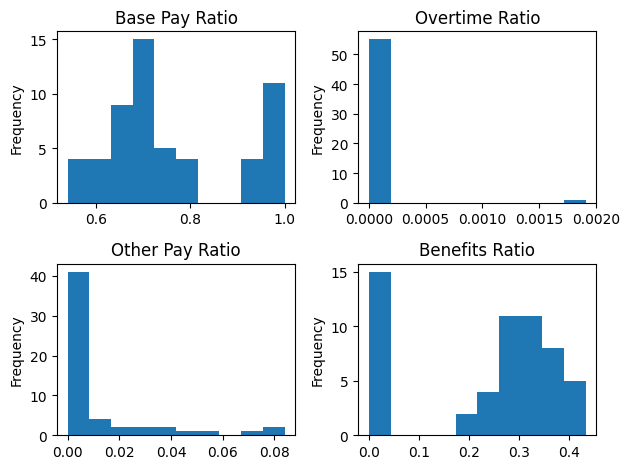

In [297]:
fig, axes = plt.subplots(nrows=2, ncols=2)
df['Base Pay Ratio'].plot(kind='hist',ax=axes[0,0], title='Base Pay Ratio')
df['Overtime Ratio'].plot(kind='hist',ax=axes[0,1], title='Overtime Ratio')
df['Other Pay Ratio'].plot(kind='hist',ax=axes[1,0], title='Other Pay Ratio')
df['Benefits Ratio'].plot(kind='hist',ax=axes[1,1], title='Benefits Ratio')
fig.tight_layout()

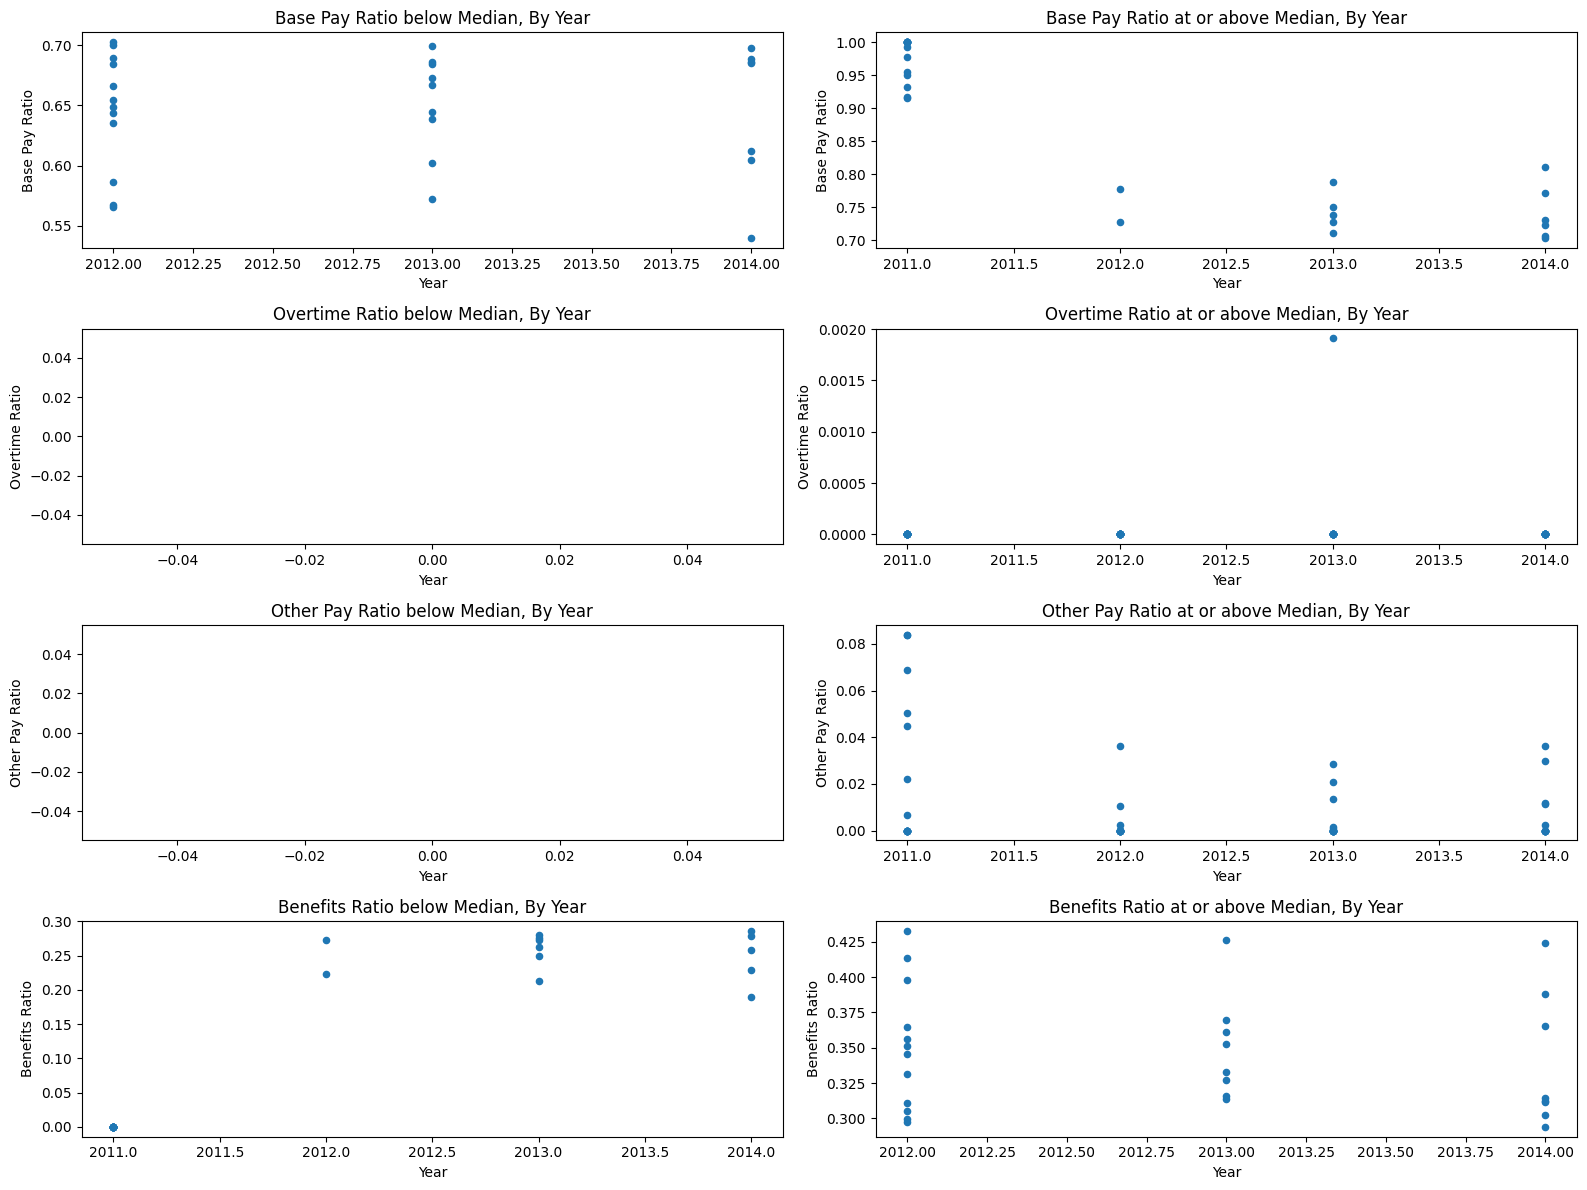

In [298]:
medians = list(df.median(numeric_only=True))

fig, axes = plt.subplots(nrows=4, ncols=2)
df[df['Base Pay Ratio'] < medians[1]].plot(kind='scatter',ax=axes[0,0], x='Year', y='Base Pay Ratio', title='Base Pay Ratio below Median, By Year')
df[df['Base Pay Ratio'] >= medians[1]].plot(kind='scatter',ax=axes[0,1], x='Year', y='Base Pay Ratio', title='Base Pay Ratio at or above Median, By Year')
df[df['Overtime Ratio'] < medians[2]].plot(kind='scatter',ax=axes[1,0], x='Year', y='Overtime Ratio',title='Overtime Ratio below Median, By Year')
df[df['Overtime Ratio'] >= medians[2]].plot(kind='scatter',ax=axes[1,1], x='Year', y='Overtime Ratio',title='Overtime Ratio at or above Median, By Year')
df[df['Other Pay Ratio'] < medians[3]].plot(kind='scatter',ax=axes[2,0], x='Year', y='Other Pay Ratio',title='Other Pay Ratio below Median, By Year')
df[df['Other Pay Ratio'] >= medians[3]].plot(kind='scatter',ax=axes[2,1], x='Year', y='Other Pay Ratio',title='Other Pay Ratio at or above Median, By Year')
df[df['Benefits Ratio'] < medians[4]].plot(kind='scatter',ax=axes[3,0], x='Year', y='Benefits Ratio',title='Benefits Ratio below Median, By Year')
df[df['Benefits Ratio'] >= medians[4]].plot(kind='scatter',ax=axes[3,1], x='Year', y='Benefits Ratio',title='Benefits Ratio at or above Median, By Year')
fig.set_size_inches(16,12)
fig.tight_layout()

In [299]:
query = """SELECT Year, AVG(TotalPay) from Salaries 
WHERE JobTitle LIKE '%mayor%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 75382.166),
 (2012, 88277.68826086957),
 (2013, 87947.18482142857),
 (2014, 87806.27377049181)]

In [300]:
query = """SELECT Year, AVG(TotalPayBenefits) from Salaries 
WHERE JobTitle LIKE '%mayor%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 75382.166),
 (2012, 127952.14239130434),
 (2013, 123201.6255357143),
 (2014, 124291.92983606557)]

In [301]:
query = """SELECT Year, AVG(OtherPay) from Salaries 
WHERE JobTitle LIKE '%mayor%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 2678.6059999999998),
 (2012, 304.62260869565216),
 (2013, 639.2342857142858),
 (2014, 669.208524590164)]

In [302]:
query = """SELECT Year, AVG(OvertimePay) from Salaries 
WHERE JobTitle LIKE '%mayor%'
GROUP By Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0.0), (2012, 0.0), (2013, 10.76125), (2014, 0.0)]

## Second Discussion

Again the mayoral staff have some strange aspects to it. Basically no overtime and other pay, though there are benefits. There are similarities to other years such as 2011 having no benefits pay, and much of the pay being base pay.

Likewise, it can be said that budget cuts affected mayoral staff as well as the other departments, with benefits being nonexistent in 2011 but returning later. Other Pay is much higher in 2011 for whatever reason, which I'll take a look at.

In [303]:
query = """SELECT JobTitle, AVG(OtherPay) from Salaries 
WHERE JobTitle LIKE '%mayor%' AND Year=='2011'
GROUP By JobTitle Order by AVG(OtherPay) DESC"""
cur.execute(query)
cur.fetchall()

[('MAYORAL STAFF XVI', 5947.8525),
 ('MAYORAL STAFF XVII', 5464.303333333333),
 ('MAYORAL STAFF XIV', 3792.855),
 ('MAYORAL STAFF X', 3545.0400000000004),
 ('MAYORAL STAFF VII', 3379.145),
 ('MAYORAL STAFF XV', 2103.1711111111113),
 ('MAYORAL STAFF XIII', 579.142),
 ('MAYORAL STAFF XII', 0.0),
 ('MAYORAL STAFF XI', 0.0),
 ('MAYORAL STAFF V', 0.0),
 ('MAYORAL STAFF IX', 0.0),
 ('MAYORAL STAFF IV', 0.0),
 ('MAYORAL STAFF II', 0.0),
 ("MAYOR'S PROGRAM MANAGER", 0.0),
 ('MAYOR', 0.0)]

In [304]:
query = """SELECT JobTitle, AVG(OtherPay) from Salaries 
WHERE JobTitle LIKE '%mayor%' AND Year=='2012'
GROUP By JobTitle Order by AVG(OtherPay) DESC"""
cur.execute(query)
cur.fetchall()

[('Mayoral Staff VII', 1674.73),
 ('Mayoral Staff XV', 1363.6228571428571),
 ('Mayoral Staff XI', 253.33333333333334),
 ('Mayoral Staff XVI', 59.63666666666666),
 ('Mayoral Staff XVII', 0.0),
 ('Mayoral Staff XIV', 0.0),
 ('Mayoral Staff XIII', 0.0),
 ('Mayoral Staff XII', 0.0),
 ('Mayoral Staff X', 0.0),
 ('Mayoral Staff V', 0.0),
 ('Mayoral Staff IX', 0.0),
 ('Mayoral Staff IV', 0.0),
 ('Mayoral Staff II', 0.0),
 ('Mayor', 0.0)]

In [305]:
query = """SELECT JobTitle, AVG(OtherPay) from Salaries 
WHERE JobTitle LIKE '%mayor%' AND Year=='2013'
GROUP By JobTitle Order by AVG(OtherPay) DESC"""
cur.execute(query)
cur.fetchall()

[('Mayoral Staff XIII', 2971.2799999999997),
 ('Mayoral Staff XV', 1713.788),
 ('Mayoral Staff V', 1662.15),
 ('Mayoral Staff II', 92.84666666666668),
 ('Mayoral Staff IV', 25.0),
 ('Mayoral Staff XVII', 0.0),
 ('Mayoral Staff XVI', 0.0),
 ('Mayoral Staff XIV', 0.0),
 ('Mayoral Staff XII', 0.0),
 ('Mayoral Staff XI', 0.0),
 ('Mayoral Staff X', 0.0),
 ('Mayoral Staff VII', 0.0),
 ('Mayoral Staff IX', 0.0),
 ('Mayor', 0.0)]

In [306]:
query = """SELECT JobTitle, AVG(OtherPay) from Salaries 
WHERE JobTitle LIKE '%mayor%' AND Year=='2014'
GROUP By JobTitle Order by AVG(OtherPay) DESC"""
cur.execute(query)
cur.fetchall()

[('Mayoral Staff VII', 3151.5),
 ('Mayoral Staff XVII', 2713.434),
 ('Mayoral Staff II', 1948.945),
 ('Mayoral Staff XIV', 1483.361),
 ('Mayoral Staff XI', 277.50625),
 ('Mayoral Staff XVI', 0.0),
 ('Mayoral Staff XV', 0.0),
 ('Mayoral Staff XIII', 0.0),
 ('Mayoral Staff X', 0.0),
 ('Mayoral Staff V', 0.0),
 ('Mayoral Staff IX', 0.0),
 ('Mayoral Staff IV', 0.0),
 ('Mayor', 0.0)]

There doesn't seem to be any pattern to the Other Pay amounts so it was probably just a unique circumstance for the pay to be fairly high relative to the other ones.

## Healthcare Jobs

In [307]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,63017.132186,2163.881550,4182.974180,0.000000,69363.987916,69363.987916
2012,67143.399901,2237.419488,4477.977724,24343.549470,73858.797113,98202.346583
2013,70970.620813,2435.224259,4937.795489,20716.044550,78343.640561,99059.685111
2014,69606.504269,2553.036031,4795.488070,21605.168667,76955.028371,98560.197038
Whole Period,67665.282319,2347.304767,4597.093273,16571.996228,74609.680359,91181.676586


In [308]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries
WHERE JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%' 
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('ADMINISTRATOR, SFGH MEDICAL CENTER', 257124.44, 2011),
 ('ASSISTANT MEDICAL EXAMINER', 1063965.86, 2011),
 ('ASSISTANT SUPERINTENDENT RECREATION', 100515.4, 2011),
 ('BUILDINGS AND GROUNDS MAINTENANCE SUPERINTENDENT', 1617180.56, 2011),
 ('CAPTAIN, EMERGENCYCY MEDICAL SERVICES', 4176262.96, 2011),
 ('CHIEF NURSERY SPECIALIST', 84800.16, 2011),
 ('CITY SHOPS ASSISTANT SUPERINTENDENT', 211724.7, 2011),
 ('CLINICAL NURSE SPECIALIST', 3464581.28, 2011),
 ('CLINICAL PHARMACIST', 4326965.74, 2011),
 ('CONFIDENTIAL CHIEF ATTORNEY II (CIVIL & CRIMINAL)', 644966.04, 2011),
 ('CONFIDENTIAL SECRETARY CITY ATTORNEY', 78482.26, 2011),
 ('CONFIDENTIAL SECRETARY TO DISTRICT ATTORNEY', 81650.52, 2011),
 ('DENTAL AIDE', 839839.18, 2011),
 ('DENTAL HYGIENIST', 245250.97999999998, 2011),
 ('DENTIST', 940939.01, 2011),
 ('EMERGENCY MEDICAL SERVICES AGENCY SPECIALIST', 434689.06, 2011),
 ('INCIDENT SUPPORT SPECIALIST', 1085669.42, 2011),
 ('LICENSED VOCATIONAL NURSE', 11591302.27, 2011),
 ('MECHANICAL S

In [309]:
query = """SELECT SUM(TotalPayBenefits), AVG(TotalPayBenefits), Count(JobTitle), Year from Salaries 
WHERE JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%'
Group by Year Order by Year"""
cur.execute(query)
cur.fetchall()

[(346819939.58, 69363.987916, 5000, 2011),
 (475888571.54, 98202.34658274867, 4846, 2012),
 (483807502.08, 99059.6851105651, 4884, 2013),
 (488760017.11, 98560.19703770922, 4959, 2014)]

In [310]:
query = """SELECT COUNT(DISTINCT(JobTitle)) from Salaries 
WHERE JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%'"""
cur.execute(query)
cur.fetchall()

[(117,)]

## First Discussion

As expected, 2011 is a bit anomalous compared to the other years, and have a lower average compensation package overall. Interestingly, 2011 is the the largest value for total jobs. It might be a good idea to see how this happened, since it may be similar to the situation with law enforcement where certain jobs seemed to have been removed or renamed. This should probably be done by each wild carded term I decided on like "%nurs%" or "%social work%".

It's interesting that this particular set of jobs has a lower average in 2011 than all of the years. Other groupings, such as law enforcement, did drop in overtime and base pay but other pay was also above average in 2011, for whatever reason. It's unlikely an important aspect, but it is an interesting aspect.

## Information Science

In [311]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle Like 'IS %'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle Like 'IS %')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,87880.755053,285.893710,2110.496782,0.000000,90277.145545,90277.145545
2012,92744.170211,669.743860,2463.887273,36274.130909,95877.801344,132151.932253
2013,104329.663742,156.749044,2358.743826,32795.109581,106845.156611,139640.266191
2014,103717.554407,77.828958,2838.901202,34937.951939,106634.284567,141572.236506
Whole Period,96440.639520,316.849271,2429.318817,25221.249608,99186.807609,124408.057217


In [312]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE 'IS %' 
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('IS ADMINISTRATOR - SUPERVISOR', 1726495.88, 2011),
 ('IS ADMINISTRATOR I', 1590517.9, 2011),
 ('IS ADMINISTRATOR II', 5240283.26, 2011),
 ('IS ADMINISTRATOR III', 5021213.36, 2011),
 ('IS BUSINESS ANALYST', 3749419.71, 2011),
 ('IS BUSINESS ANALYST - ASSISTANT', 402719.26, 2011),
 ('IS BUSINESS ANALYST - PRINCIPAL', 9362690.14, 2011),
 ('IS BUSINESS ANALYST - SENIOR', 6840487.08, 2011),
 ('IS ENGINEER - ASSISTANT', 458708.65, 2011),
 ('IS ENGINEER - JOURNEY', 4953835.37, 2011),
 ('IS ENGINEER - PRINCIPAL', 5551206.92, 2011),
 ('IS ENGINEER - SENIOR', 9419740.65, 2011),
 ('IS OPERATOR - ANALYST', 135014.53, 2011),
 ('IS OPERATOR - JOURNEY', 627542.11, 2011),
 ('IS OPERATOR - SENIOR', 885641.38, 2011),
 ('IS OPERATOR - SUPERVISOR', 118248.12000000001, 2011),
 ('IS PROGRAMMER ANALYST', 719998.05, 2011),
 ('IS PROGRAMMER ANALYST - ASSISTANT', 179644.0, 2011),
 ('IS PROGRAMMER ANALYST - PRINCIPAL', 2035024.98, 2011),
 ('IS PROGRAMMER ANALYST - SENIOR', 1990660.77, 2011),
 ('IS PROJECT DI

## Justice

In [313]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%defender%' OR JobTitle LIKE '%court%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%defender%' OR JobTitle LIKE '%court%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,70014.457500,15.229854,2603.914142,0.000000,72633.601496,72633.601496
2012,66080.436185,11.800361,2467.031365,28799.905884,68559.267912,97359.173795
2013,68507.133023,1.713004,5149.386198,24983.115779,73658.232224,98641.348004
2014,95836.930968,0.000000,491.393871,33785.266129,96328.324839,130113.590968
Whole Period,68797.053500,9.434548,3355.793462,17798.387573,72162.281510,89960.669083


In [314]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%defender%' OR JobTitle LIKE '%court%' 
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('ASSISTANT COURT REPORTER COORDINATOR', 126571.71, 2011),
 ('CHIEF PROBATION OFFICER, JUVENILE COURT', 191319.45, 2011),
 ('COUNSELOR, FAMILY COURT SERVICE', 813110.78, 2011),
 ('COURT AD RESOLUTION COORDINATOR', 83002.23, 2011),
 ('COURT ADMINISTRATIVE SECRETARY', 65504.38, 2011),
 ('COURT ADMINISTRATOR', 400805.44, 2011),
 ('COURT ALTERNATIVE SPECIALIST I', 235546.07, 2011),
 ('COURT ASSISTANT - SENIOR, SUPERIOR COURT', 648655.49, 2011),
 ('COURT ASSISTANT, SUPERIOR COURT', 77698.6, 2011),
 ('COURT CLERK', 76467, 2011),
 ('COURT COMMISSIONER', 1277188.01, 2011),
 ('COURT COMPUTER APPLICATIONS ANALYST', 287529.38, 2011),
 ('COURT COMPUTER APPLICATIONS PROGRAMMER', 343004.54000000004, 2011),
 ('COURT COMPUTER FACILITIES COORDINATOR', 120994.6, 2011),
 ('COURT COMPUTER SYSTEMS ENGINEER II', 418416.26, 2011),
 ('COURT COMPUTER SYSTEMS MANAGER', 413318.4, 2011),
 ('COURT EXECUTIVE OFFICER', 176028.39, 2011),
 ('COURT INTERPRETER', 967236.32, 2011),
 ('COURT INTERPRETER SUPERVISOR', 9691

## Engineers and Scientists

In [315]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%bio%' OR JobTitle LIKE '%chem%' OR JobTitle LIKE '%research%' OR JobTitle LIKE '%engineer%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%bio%' OR JobTitle LIKE '%chem%' OR JobTitle LIKE '%research%' OR JobTitle LIKE '%engineer%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,84912.140763,2437.311825,3951.215798,0.000000,91300.668386,91300.668386
2012,91368.620392,2384.216322,3669.196180,36046.073411,97422.032894,133468.106305
2013,96797.484386,2677.754223,3561.438927,31258.550129,103036.677536,134295.227665
2014,96979.440230,2648.329480,3437.038509,33508.070775,103064.808220,136572.878995
Whole Period,91738.323790,2527.947495,3685.160393,22499.888972,97951.431678,120451.320650


In [316]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%bio%' OR JobTitle LIKE '%chem%' OR JobTitle LIKE '%research%' OR JobTitle LIKE '%engineer%'
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('ADMINISTRATIVE ENGINEER', 1279614.3, 2011),
 ('APPRENTICE STATIONARY ENGINEER', 781299.21, 2011),
 ('APPRENTICE STATIONARY ENGINEER, SEWAGE PLANT', 924409.73, 2011),
 ('APPRENTICE STATIONARY ENGINEER,WATER TREATMENT PLN',
  354166.83999999997,
  2011),
 ('ASSISTANT ENGINEER', 12309576.12, 2011),
 ('ASSOCIATE ENGINEER', 14690033.17, 2011),
 ('BIOLOGIST I/II', 1889652.18, 2011),
 ('BIOLOGIST III', 378200.89, 2011),
 ('BUILDING PLANS ENGINEER', 280357.51, 2011),
 ('CHEMIST I/II', 1579424.31, 2011),
 ('CHEMIST III', 551959.15, 2011),
 ('CHIEF MICROBIOLOGIST', 114141.76, 2011),
 ('CHIEF STATIONARY ENGINEER', 1605804.76, 2011),
 ('CHIEF STATIONARY ENGINEER, SEWAGE PLANT', 2354623.98, 2011),
 ('CHIEF STATIONARY ENGINEER, WATER TREATMENT PLANT', 652271.55, 2011),
 ('CIVIL ENGINEERING ASSISTANT', 990643.6900000001, 2011),
 ('CIVIL ENGINEERING ASSOCIATE I', 2600551.14, 2011),
 ('COURT COMPUTER SYSTEMS ENGINEER II', 418416.26, 2011),
 ('ELECTRICAL ENGINEERING ASSOCIATE I', 74573.05, 2011),
 ('

## Planning

In [317]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle Like '%plann%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle Like '%plann%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,82173.855620,91.855659,889.866008,0.000000,83155.577287,83155.577287
2012,82437.836852,88.763407,1200.252407,32873.335889,83726.852667,116600.188556
2013,79551.104338,134.177715,953.099404,25903.177914,80638.381457,106541.559371
2014,79453.961138,78.078523,1040.354769,28046.918246,80572.394431,108619.312677
Whole Period,80784.451584,98.322139,1021.302944,22349.618052,81904.076667,104253.694719


In [318]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%plann%' 
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('AIRPORT ECONOMIC PLANNER', 1407442.68, 2011),
 ('AIRPORT EMERGENCY PLANNING COORDINATOR', 151731.87, 2011),
 ('CITY PLANNING GRAPHICS SUPERVISOR', 65698.95, 2011),
 ('CITY PLANNING INTERN', 16835.52, 2011),
 ('EMERGENCY PLANNING COORDINATOR', 83213.51, 2011),
 ('HEALTH PROGRAM PLANNER', 396981.07, 2011),
 ('MAINTENANCE PLANNER', 2108208.4, 2011),
 ('PLANNER I', 255067.08, 2011),
 ('PLANNER II', 2170648.62, 2011),
 ('PLANNER III', 4602297.62, 2011),
 ('PLANNER III-ENVIRONMENTAL REVIEW', 1508373.53, 2011),
 ('PLANNER IV', 2323978.91, 2011),
 ('PLANNER IV-ENVIRONMENTAL REVIEW', 1486604.2, 2011),
 ('PLANNER TECHNICIAN', 109040.84, 2011),
 ('PLANNER V', 553731.72, 2011),
 ('SENIOR HEALTH PROGRAM PLANNER', 808115.24, 2011),
 ('TRANSIT PLANNER II', 750115.44, 2011),
 ('TRANSIT PLANNER III', 1042628.37, 2011),
 ('TRANSIT PLANNER IV', 1613425.3699999999, 2011),
 ('Airport Economic Planner', 5692939.71, 2012),
 ('Airport Emerg Planning Coord', 928206.43, 2012),
 ('City Planning Intern', 27247

## Technician and Mechanics

In [319]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%automotive%' OR JobTitle LIKE '%electr%' OR JobTitle LIKE '%mech%' OR JobTitle LIKE '%plumb%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%automotive%' OR JobTitle LIKE '%electr%' OR JobTitle LIKE '%mech%' OR JobTitle LIKE '%plumb%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,74955.826324,13958.064253,5654.070055,0.000000,94567.960632,94567.960632
2012,75562.768912,13052.822727,5462.366340,32775.637879,94077.957980,126853.595859
2013,79770.850461,12991.595673,5311.233124,28262.300658,98073.679259,126335.979917
2014,78453.838769,13339.938791,5304.627892,29653.685085,97098.405453,126752.090538
Whole Period,77229.464234,13330.743749,5429.610847,22899.074380,95989.818830,118888.893210


In [320]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%automotive%' OR JobTitle LIKE '%electr%' OR JobTitle LIKE '%mech%' OR JobTitle LIKE '%plumb%'
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('AIRPORT ELECTRICIAN', 1848033.08, 2011),
 ('AIRPORT ELECTRICIAN SUPERVISOR', 234177.52, 2011),
 ('AIRPORT MECHANICAL MAINTENANCE SUPERVISOR', 128534.17, 2011),
 ('ASSISTANT ELECTRONIC MAINTENANCE TECHNICIAN', 909281.29, 2011),
 ('AUTOMOTIVE BODY AND FENDER WORKER', 3301538.25, 2011),
 ('AUTOMOTIVE BODY AND FENDER WORKER SUPERVISOR I', 122486.89, 2011),
 ('AUTOMOTIVE MACHINIST', 4847301.46, 2011),
 ('AUTOMOTIVE MACHINIST ASSISTANT SUPERVISOR', 878085.24, 2011),
 ('AUTOMOTIVE MACHINIST SUPERVISOR I', 740575.67, 2011),
 ('AUTOMOTIVE MECHANIC', 11459670.73, 2011),
 ('AUTOMOTIVE MECHANIC ASSISTANT SUPERVISOR', 1216416.77, 2011),
 ('AUTOMOTIVE MECHANIC SUPERVISOR I', 757023.84, 2011),
 ('AUTOMOTIVE SERVICE WORKER', 7877348.06, 2011),
 ('AUTOMOTIVE SERVICE WORKER ASSISTANT SUPERVISOR', 348525.52, 2011),
 ('AUTOMOTIVE TRANSIT SHOP SUPERVISOR I', 649310.36, 2011),
 ('CHIEF ELECTRICAL INSPECTOR', 123080.71, 2011),
 ('CHIEF PLUMBING INSPECTOR', 127938.44, 2011),
 ('CRANE MECHANIC SUPERVISOR', 

## Clerks

In [321]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%clerk%' OR JobTitle LIKE '%secretar%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%clerk%' OR JobTitle LIKE '%secretar%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df.head()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits
2011,45678.960795,676.798348,716.119946,0.000000,47071.879090,47071.879090
2012,47756.876236,823.594942,816.862004,22871.135076,49397.333181,72268.468257
2013,51934.891126,833.510974,1091.117597,21248.152803,53859.519696,75107.672499
2014,47691.562430,1142.961062,675.213885,20856.503618,49509.737377,70366.240995
Whole Period,48252.489534,863.563736,826.190670,16095.120303,49942.243941,66037.364245


In [322]:
query = """SELECT JobTitle, SUM(TotalPayBenefits), Year from Salaries 
WHERE JobTitle LIKE '%clerk%' OR JobTitle LIKE '%secretar%' 
Group by JobTitle Order by Year"""
cur.execute(query)
cur.fetchall()

[('ACCOUNT CLERK', 3654960.14, 2011),
 ('ASSESSMENT CLERK', 1159123.58, 2011),
 ('ASSISTANT CLERK, BOARD OF SUPERVISORS', 367402.07, 2011),
 ('BOARD SECRETARY - MUNICIPAL TRANSPORTATION AGENC', 154690.6, 2011),
 ('BOARD/COMMISSION SECRETARY III', 94919.25, 2011),
 ('CHIEF CLERK', 1021800.75, 2011),
 ('CHIEF PAYROLL AND PERSONNEL CLERK', 223541.26, 2011),
 ('CLAIMS PROCESS CLERK', 96239.16, 2011),
 ('CLERK', 6344052.82, 2011),
 ('CLERK TYPIST', 5862695.17, 2011),
 ('CONFIDENTIAL SECRETARY CITY ATTORNEY', 78482.26, 2011),
 ('CONFIDENTIAL SECRETARY TO DISTRICT ATTORNEY', 81650.52, 2011),
 ('COURT ADMINISTRATIVE SECRETARY', 65504.38, 2011),
 ('COURT CLERK', 76467, 2011),
 ('DEPUTY COURT CLERK I', 90607.64, 2011),
 ('DEPUTY COURT CLERK II', 9639324.68, 2011),
 ('DEPUTY COURT CLERK III', 7967237.15, 2011),
 ('ELECTIONS CLERK', 562817.2, 2011),
 ('EXECUTIVE SECRETARY I', 3862906.19, 2011),
 ('EXECUTIVE SECRETARY II', 4102601.64, 2011),
 ('EXECUTIVE SECRETARY III', 1159950.64, 2011),
 ('EXECUT